<a href="https://colab.research.google.com/github/Davron030901/Machine_Learning/blob/main/module5_class1_kmeans_explained.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 5 · Class 1 — K-Means Clustering
### How to group data when there are **no labels**

**Level:** A2 English. No math. Real datasets, real pictures, real reasons.

> **How to use this notebook:** read the text, run the code cell under it (Shift+Enter), and look at
> the result. The tables, pictures and the story are the lesson. Do not rush.

## What data will we use? (read this first)

This class uses a few small, real datasets. Here they are, in one line each:

| Dataset | What it is | Has a label? | Used for |
| --- | --- | --- | --- |
| **Iris** | 150 flowers with 4 measurements | **Yes** (species) | show *supervised* |
| **Mall Customers** | 200 shoppers (age, income, spending) | **No** | show *unsupervised* + clustering |
| **Anvar's 6 customers** | a tiny made-for-teaching set | No | learn K-Means step by step |
| **A photo (china.jpg)** | a normal picture | No | show clustering on an image |

> Do not worry about the names yet. We meet each one when we need it. The two that matter most are
> **Iris** (has an answer) and **Mall Customers** (has no answer) — they show the whole point of this module.

## 0. Run this first (loads tools + datasets)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris, load_digits, load_sample_image
np.random.seed(42)
print('Ready.')

Ready.


## 1. The big change from Module 4

In **Module 4** every row had an **answer** (a label `y`): spam or not? price? rating?
The model learned from those answers. That is **supervised learning** (_the data has a teacher_).

In **Module 5** the data has **no answers** — only the features `X`. The new job: **find the groups
hidden in the data**. That is **unsupervised learning** (_no teacher_).

> **🍽️ Everyday picture:** *Supervised* is studying with an **answer key** — every question has the
> correct answer next to it, so you learn the pattern. *Unsupervised* is being handed a **big basket of
> mixed laundry** with no instructions and told "sort it into groups." Nobody says what the groups are —
> you make them yourself by putting similar clothes together (darks, whites, towels…). That sorting is **clustering**.

The fastest way to feel the difference is to look at **two real datasets** side by side. Let us do that now.

## 2. A real **supervised** dataset — Iris (it HAS a label)

**Iris**: 150 real flowers, each measured 4 ways, each one **already labeled** with its species.
That label is the **answer** a model would learn to predict.

| sepal length | sepal width | petal length | petal width | **species (LABEL)** |
| --- | --- | --- | --- | --- |
| 5.1 | 3.5 | 1.4 | 0.2 | **setosa** |
| 4.9 | 3.0 | 1.4 | 0.2 | **setosa** |
| 4.7 | 3.2 | 1.3 | 0.2 | **setosa** |
| 4.6 | 3.1 | 1.5 | 0.2 | **setosa** |

The last column is the **answer key**. Run it and see the real table:

In [2]:
iris = load_iris(as_frame=True)
df_iris = iris.frame.copy()
df_iris['species'] = df_iris['target'].map(dict(enumerate(iris.target_names)))
df_iris = df_iris.drop(columns='target')
print('Shape:', df_iris.shape, '| LABEL column = species')
df_iris.head()

Shape: (150, 5) | LABEL column = species


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 3. A real **unsupervised** dataset — Mall Customers (NO label)

**Mall Customers**: 200 real shoppers (this is the dataset we use all of Module 5). We know facts about
each one, but there is **no 'customer type' column**. Nobody labeled them. We must find the types ourselves.

| CustomerID | Genre | Age | Annual Income (k$) | Spending Score (1-100) |
| --- | --- | --- | --- | --- |
| 0001 | Male | 19 | 15 | 39 |
| 0002 | Male | 21 | 15 | 81 |
| 0003 | Female | 20 | 16 | 6 |
| 0004 | Female | 23 | 16 | 77 |

There is **no answer column**. Run it and confirm:

In [3]:
df_mall = pd.read_csv('https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2024%20-%20K-Means%20Clustering/Mall_Customers.csv')
print('Shape:', df_mall.shape, '| columns:', list(df_mall.columns))
print('Notice: NO label / answer column.')
df_mall.head()

Shape: (200, 5) | columns: ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Notice: NO label / answer column.


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 4. Compare them directly

| | Supervised — Iris | Unsupervised — Mall Customers |
| --- | --- | --- |
| Is there an answer/label column? | **Yes** — `species` | **No** |
| The goal | Predict the answer for new rows | Find hidden groups |
| Example question | "Is this flower a setosa?" | "Which shoppers are alike?" |
| Module | Module 4 | Module 5 (this one) |
| Main tools | Logistic Regression, Random Forest | **K-Means**, DBSCAN |

> **The single test:** look for an **answer column**. Found one → supervised. None → unsupervised.

The same difference, as a picture: **left** = Iris, colored by its known species (the answer is given).
**right** = Mall Customers, all grey (no answer — we must find the groups).

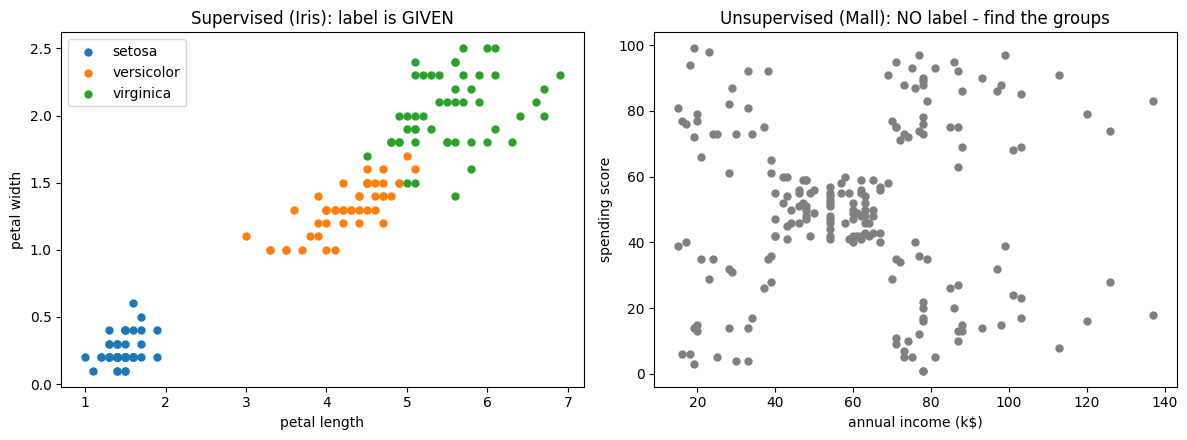

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
# Supervised: color by the KNOWN label
for sp, grp in df_iris.groupby('species'):
    ax[0].scatter(grp['petal length (cm)'], grp['petal width (cm)'], label=sp, s=25)
ax[0].set_title('Supervised (Iris): label is GIVEN'); ax[0].legend()
ax[0].set_xlabel('petal length'); ax[0].set_ylabel('petal width')
# Unsupervised: no label -> all grey
ax[1].scatter(df_mall['Annual Income (k$)'], df_mall['Spending Score (1-100)'], c='grey', s=25)
ax[1].set_title('Unsupervised (Mall): NO label - find the groups')
ax[1].set_xlabel('annual income (k$)'); ax[1].set_ylabel('spending score')
plt.tight_layout(); plt.show()

On the **right**, can you already spot a few blobs by eye? K-Means will turn those grey dots into
named customer groups — that is the rest of this lesson.

## 5. The same difference in **Computer Vision** (images)

Images follow the exact same rule. The 'features' are the **pixels**; the question is whether there is a **label**.

**Supervised vision:** the `digits` dataset — 1,797 real images of handwritten numbers, each **labeled**
with the correct digit. A model learns *pixels → which digit*. Each image comes with its answer:

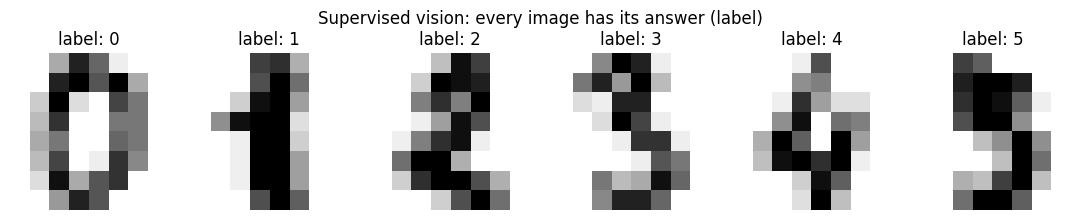

In [5]:
digits = load_digits()
fig, ax = plt.subplots(1, 6, figsize=(11, 2.2))
for i in range(6):
    ax[i].imshow(digits.images[i], cmap='gray_r')
    ax[i].set_title(f'label: {digits.target[i]}'); ax[i].axis('off')
plt.suptitle('Supervised vision: every image has its answer (label)')
plt.tight_layout(); plt.show()

**Unsupervised vision:** a photo with **no labels**. We use **K-Means** to group the photo's many
thousands of colors into just **16 color-groups**, then repaint each pixel with its group color.
Nobody told K-Means the colors — it finds the 16 main color-groups **itself** (this is clustering on pixels).

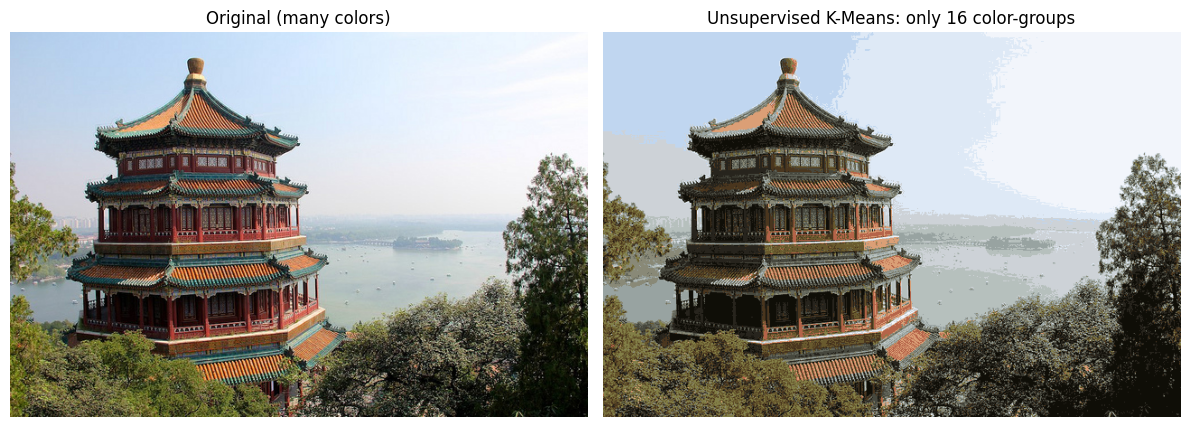

In [6]:
china = load_sample_image('china.jpg')
pixels = china.reshape(-1, 3) / 255.0
sample = pixels[np.random.RandomState(0).choice(len(pixels), 10000, replace=False)]
km_img = KMeans(n_clusters=16, random_state=42, n_init=4).fit(sample)
china_16 = km_img.cluster_centers_[km_img.predict(pixels)].reshape(china.shape)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(china); ax[0].set_title('Original (many colors)'); ax[0].axis('off')
ax[1].imshow(china_16); ax[1].set_title('Unsupervised K-Means: only 16 color-groups'); ax[1].axis('off')
plt.tight_layout(); plt.show()

| | Supervised vision (digits) | Unsupervised vision (color compression) |
| --- | --- | --- |
| Label? | Yes — the true digit | No |
| Goal | Predict the digit | Group similar colors |

> Same rule as the tables: **a label makes it supervised; no label makes it unsupervised.**

## 6. Why we even need this — a real situation

Meet **Anvar**. He runs an online shop. His customer data looks **exactly like the Mall Customers table
above**: age, income, spending — and **no 'customer type' column**. He wants to:

- send big spenders a **VIP offer**,
- send people who stopped buying a **"we miss you" coupon**,
- send discount-only buyers a **sale alert**.

| Option | Problem |
| --- | --- |
| Read all 5,000 profiles by hand | Impossible — too slow, many columns each |
| Treat everyone the same | He wastes the VIP offer on people who never spend |
| **Let the data form the groups itself** | ✅ This is **clustering** — why we need it |

**The core reason:** the customer types are real but **hidden** — nobody labeled them.
We need a tool that reads the numbers and forms the groups for us. That tool is **K-Means**.

## 7. The same idea is everywhere

- **News sites:** group thousands of articles by topic when nobody tagged them.
- **Photos:** shrink millions of colors to 16 (you just saw this).
- **Banks:** group normal transactions; a payment that fits **no** group looks suspicious (fraud).
- **Hospitals:** group patients with similar symptoms to spot a new pattern.

Whenever you think **"there are types in here, but nobody labeled them"** → it is a clustering job.

## 8. Start tiny — 6 of Anvar's customers

To learn K-Means we use just **6 customers**. Two facts each: **x = visits per month**, **y = money spent**.

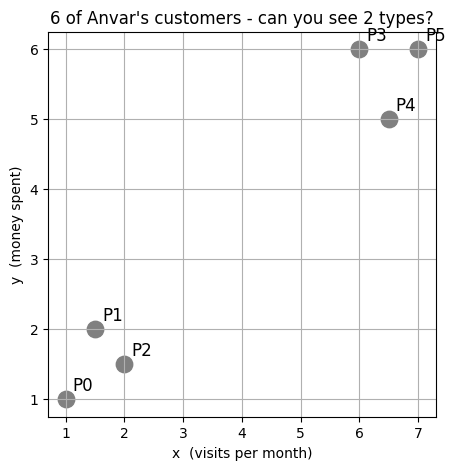

In [7]:
X = np.array([[1,1],[1.5,2],[2,1.5],[6,6],[6.5,5],[7,6]], dtype=float)
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], s=140, color='grey')
for i,(x,y) in enumerate(X): plt.text(x+0.12, y+0.12, f'P{i}', fontsize=12)
plt.xlabel('x  (visits per month)'); plt.ylabel('y  (money spent)')
plt.title("6 of Anvar's customers - can you see 2 types?"); plt.grid(True); plt.show()

Your eyes see **two types**: bottom-left = rare, low spenders (P0–P2); top-right = frequent, big spenders
(P3–P5). With 5,000 customers and 8 facts each, eyes fail — so let K-Means find them by itself.

## 9. Watch K-Means think (the 4 steps, drawn)

Tell it **K = 2** (we want 2 types). Then it repeats:

1. **Drop K centers** somewhere (we start them in a *bad* spot on purpose, to see them move).
2. **Assign:** each customer joins the **nearest** center.
3. **Move:** each center jumps to the **middle** of its customers.
4. **Repeat** 2–3 until the centers stop moving.

> **🏀 Everyday picture (remember this one):** a school gym full of students. You drop **2 teachers** in
> random spots. **Step 1:** every student walks to the **nearest teacher**. **Step 2:** each teacher walks to
> the **middle of their own students**. Now some students are closer to the *other* teacher, so they switch —
> and the teachers move again. Repeat until nobody switches and the teachers stop walking. **That is K-Means.**
> Students = data points, teachers = centers.

> **"Nearest" just means** how close two dots look on the picture. No formula — closer dot, closer flag.

The helper steps:

In [8]:
def assign(X, centers):
    dist = np.linalg.norm(X[:,None,:] - centers[None,:,:], axis=2)  # how far each point is from each center
    return dist.argmin(axis=1)                                      # join the nearest center

def move(X, labels, K):
    return np.array([X[labels==k].mean(axis=0) for k in range(K)])  # center -> middle of its points

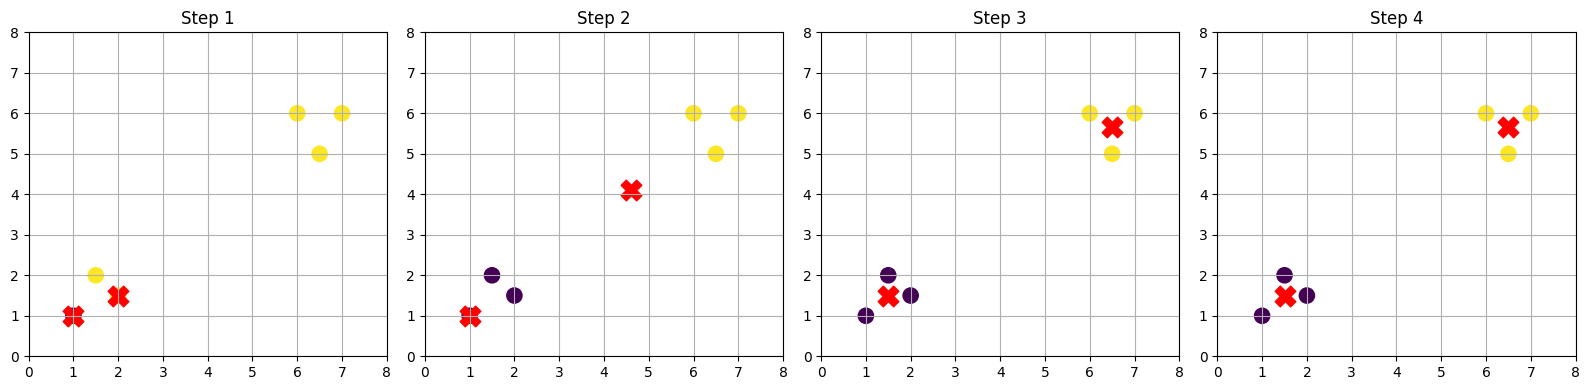

Final centers:
[[1.5  1.5 ]
 [6.5  5.67]]


In [9]:
centers = np.array([[1.0,1.0],[2.0,1.5]])   # BAD start: both near bottom-left
K = 2
fig, ax = plt.subplots(1, 4, figsize=(16,4))
for step in range(4):
    labels = assign(X, centers)
    a = ax[step]
    a.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=120)
    a.scatter(centers[:,0], centers[:,1], c='red', marker='X', s=220)
    a.set_title(f'Step {step+1}'); a.grid(True); a.set_xlim(0,8); a.set_ylim(0,8)
    centers = move(X, labels, K)
plt.tight_layout(); plt.show()
print('Final centers:'); print(centers.round(2))

Read left to right: both centers start in the bottom-left, then one **climbs** to the big-spender group
and they settle. When the colors stop changing, K-Means has **converged** (finished).
That is the whole secret: **assign → move → assign → move →** … until nothing changes.

## 10. Why does such a simple idea actually work?

Think of each center as a **flag**, and each customer holding a rope to the **nearest** flag.

- A customer joining the nearest flag makes the ropes **shorter**.
- A flag moving to the middle of its customers makes the ropes **shorter again**.

Every step can only make the total rope length **shorter or equal — never longer**. So the flags slide
to the natural centers of the crowd and **lock in place**. That lock-in is convergence.

> **One sentence:** K-Means works because each step makes the groups a little tighter, and
> 'a little tighter' can only continue until they are as tight as possible.

**One catch:** the *starting* spot can change the final answer a bit — so we use `n_init=10`
(try 10 starts, keep the tightest).

## 11. What 'nearest center' looks like (the map)

"Join the nearest center" splits the space into **regions**. A **new** customer just falls into a region,
so Anvar instantly knows their type — no re-running needed.

In [ ]:
km = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X)
xx, yy = np.meshgrid(np.linspace(0,8,300), np.linspace(0,8,300))
zz = km.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.figure(figsize=(5,5))
plt.contourf(xx, yy, zz, alpha=0.25, cmap='viridis')
plt.scatter(X[:,0], X[:,1], c=km.labels_, cmap='viridis', s=140, edgecolor='k')
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], c='red', marker='X', s=240)
plt.title('Two regions: each side belongs to one center'); plt.grid(True); plt.show()

## 12. The short way — scikit-learn does all 4 steps

In [ ]:
km = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X)
print('Group of each customer:', km.labels_)
print('Centers:'); print(km.cluster_centers_.round(2))

You get `[0 0 0 1 1 1]` and centers ≈ `[1.5,1.5]`, `[6.5,5.67]` — exactly the by-hand result.

> The group numbers (0,1) are only names. K-Means does not say which is 'better'. **You** name them later.

## 13. A bigger example — 150 customers, 3 types

Real data is bigger. 150 customers; by eye the types are fuzzy — K-Means separates them cleanly.

In [ ]:
from sklearn.datasets import make_blobs
X3, _ = make_blobs(n_samples=150, centers=3, cluster_std=1.1, random_state=7)
km3 = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X3)
fig, ax = plt.subplots(1,2, figsize=(11,4))
ax[0].scatter(X3[:,0], X3[:,1], c='grey', s=25); ax[0].set_title('Before: 150 grey dots')
ax[1].scatter(X3[:,0], X3[:,1], c=km3.labels_, cmap='viridis', s=25)
ax[1].scatter(km3.cluster_centers_[:,0], km3.cluster_centers_[:,1], c='red', marker='X', s=220)
ax[1].set_title('After: K-Means found 3 types')
for a in ax: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

## 14. How you actually use K-Means at work

The colors are useless until you **look at each group and give it a name**. The real recipe:

1. **Pick the facts** that matter (visits, money, days since last order).
2. **Scale them** (next section — not optional).
3. **Choose K** with the elbow (section 15).
4. **Run K-Means** → a group number per customer.
5. **Look at each group's averages and name it:** high money+visits → **VIP**; old last-order → **sleeping**; discount-only → **bargain hunter**.
6. **Act** — send each named group its own message.

> **The point is steps 5–6, not step 4.** Group `2` means nothing; *'VIP customers'* means everything.
> Turning `2` into *'VIP'* and saying what to do about it is your real job as the analyst.

## 15. How many groups? The **elbow** method

With 5,000 customers you cannot count by eye. We measure **inertia**
(_how tight the groups are: total rope length to centers; **smaller = tighter**_). More groups always
lowers it, so we find the **elbow** — where the line stops dropping fast and goes flat.

> **🍕 Everyday picture:** buying pizzas for a party. 0→1 pizza: huge help. 1→2: big help. 2→3: still good.
> But once everyone is full, more pizzas barely help — money wasted. The **elbow** is the point where one
> more group (one more pizza) stops making a real difference.

In [ ]:
Ks = range(1,8)
inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X3).inertia_ for k in Ks]
plt.figure(figsize=(6,4))
plt.plot(list(Ks), inertias, 'o-')
plt.scatter([3],[inertias[2]], s=300, facecolors='none', edgecolors='red', linewidths=2)
plt.annotate('elbow = 3', (3, inertias[2]), textcoords='offset points', xytext=(30,20), color='red')
plt.xlabel('K'); plt.ylabel('inertia (lower = tighter)'); plt.title('Elbow method'); plt.grid(True); plt.show()

The line bends hard at **K = 3**, then flattens. That bend = the elbow → **3 types is right.**

## 16. The #1 mistake — forgetting to **scale**

K-Means measures distance. If money is 0–100,000 and visits is 0–10, money **drowns out** visits —
the groups become 'money only'. Same customers, **without** vs **with** scaling:

> **⚖️ Everyday picture:** two judges score a contest. Judge A gives 0–10. Judge B gives 0–1,000,000.
> If you just add their scores, Judge B **completely decides** the winner — Judge A is ignored. Unfair!
> **Scaling** puts both judges on the same range so each counts equally. K-Means *without* scaling = letting
> the big-number judge (money) decide everything.

In [ ]:
v = np.concatenate([np.random.normal(2,0.7,30), np.random.normal(5,0.7,30), np.random.normal(8,0.7,30)])
m = np.concatenate([np.random.normal(30000,8000,30), np.random.normal(60000,8000,30), np.random.normal(30000,8000,30)])
Xc = np.column_stack([v, m])
from sklearn.preprocessing import StandardScaler
lab_raw    = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(Xc)
lab_scaled = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(StandardScaler().fit_transform(Xc))
fig, ax = plt.subplots(1,2, figsize=(12,4.5))
ax[0].scatter(Xc[:,0], Xc[:,1], c=lab_raw, cmap='viridis', s=30)
ax[0].set_title('WITHOUT scaling\n(split by money only - flat bands)')
ax[1].scatter(Xc[:,0], Xc[:,1], c=lab_scaled, cmap='viridis', s=30)
ax[1].set_title('WITH scaling\n(respects BOTH visits and money)')
for a in ax: a.set_xlabel('visits'); a.set_ylabel('money spent')
plt.tight_layout(); plt.show()

**Left:** flat bands — only money decided the groups (its numbers are thousands of times bigger).
**Right:** both facts matter. → **Rule:** before K-Means, almost always `StandardScaler().fit_transform(X)`.

## 17. What 'wrong K' looks like
Pick K too big → K-Means cuts good types into meaningless pieces. K=3 vs K=6 on the same data:

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(11,4))
for a, k in zip(ax, [3, 6]):
    lab = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X3)
    a.scatter(X3[:,0], X3[:,1], c=lab, cmap='tab10', s=25)
    a.set_title(f'K = {k}' + ('  (right)' if k==3 else '  (too many)'))
    a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

## 18. When to use K-Means — and when NOT

**Use it when:** no labels; groups are roughly **round and similar in size**; features are numbers you can scale.

**Do NOT use it when:** you already have labels (that is Module 4); the groups are long curvy shapes
(moons, rings) — K-Means cuts them wrong (next class: DBSCAN fixes this); the elbow is totally unclear.

> Knowing when a tool is the **wrong** tool is what separates a real analyst from someone who just runs code.

## 19. Common mistakes

| Mistake | Why it is wrong |
| --- | --- |
| Not scaling first | Big-number facts drown small ones (section 16). |
| Thinking group `0` is 'better' than `1` | The numbers are just names, no order. |
| Stopping at the colors | The job is **naming** each group and acting (section 14). |
| Picking a huge K | Groups get cut into meaningless pieces (section 17). Use the elbow. |
| Using K-Means when you have labels | That is supervised learning (Module 4). |
| Running it once | The random start matters. `n_init=10` keeps the best of 10 starts. |

## 20. Summary

- **Supervised vs unsupervised:** the test is one question — **is there a label/answer column?**
  (Iris has one → M4; Mall Customers has none → M5). Same rule for images (labeled digits vs color compression).
- **Why we need clustering:** real types are hidden and nobody labeled them (Anvar / Mall Customers).
- **How K-Means works:** pick K, drop centers, repeat **assign → move** until tight (convergence) —
  it works because every step makes groups tighter.
- **How to use it at work:** run it, then **name each group** and **act**.
- **Choose K** with the **elbow**; **always scale**; know **when not** to use it.

**Next class:** when K-Means fails (curvy shapes) — Hierarchical Clustering and DBSCAN.

---
## Assignment

Put your **full name** in the first code cell as a comment, then:

1. **In your own words:** look at the Iris and Mall Customers tables (sections 2–3). For each, say if it is
   supervised or unsupervised and **point to the exact reason** (which column, or the missing column).
2. **Comment every line** of sections 9 and 16.
3. **New types:** change `centers=3` to `centers=4` in section 13's data, re-cluster with K=4. Clean 4 types?
4. **Elbow:** redraw the elbow for that 4-type data. Is the elbow now at 4?
5. **Name the groups:** for section 13's 3 groups, invent a real customer-type name for each and say why.

> Save as `lesson-...ipynb` and submit it in the week's submissions folder.

In [ ]:
# Your name: ____________________
# Task 3 starter:
# X4, _ = make_blobs(n_samples=200, centers=4, cluster_std=1.0, random_state=7)
# ... your code here ...